# Figure 5S1: Bound Difference by Decision Time

Supplemental to `Figure05_mixedVsBlockedSNR.m`

## What this notebook does

Shows how the difference between high-SNR and low-SNR decision bounds varies with
Decision Time (DT) for each task block, in both task variants:

- **OL (Blocked SNR)**: Each block contains only one SNR level; subjects know which SNR applies.
- **MX (Mixed SNR)**: Multiple SNR levels are interleaved within a block; subjects must infer the SNR.

**Figure** — 2 rows (OL / MX) × 3 columns (blocks 1–3):
Hi − Lo SNR bound difference per DT bin (1–10 steps). Individual subject values in light grey
(jittered along x); group mean as a red circle (filled if Wilcoxon p < 0.05 vs. 0, open otherwise).

**Data**: Blocks 1–3, pre-filtered to `DT > 2` (keeps DT ≥ 3), all subjects.

## Imports

Standard scientific Python libraries plus `get_data_table` and `get_bound_summary`.
No data loading or analysis here.

## Load data

Loads both task variants with default settings (bound/DT computation, wall-hit marking,
bias correction, block merging 6 → 3). No trials are dropped at this stage.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats

from pigeon.data import get_data_table
from pigeon.stats import get_bound_summary
from pigeon.pathDefaults import FIGURES_DIR

In [2]:
data_table_ol = get_data_table(task_type='OL')
data_table_mx = get_data_table(task_type='MX')

  1: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_14h39.24.096.csv
  2: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_15h37.48.260.csv
  3: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h34.46.761.csv
  4: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h35.25.285.csv
  5: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.33.669.csv
  6: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.41.364.csv
  7: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.49.086.csv
  8: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

## Parameters and helper

**`MIN_DT`**: Pre-filter applied before `get_bound_summary`; keeps DT ≥ 3 (matching MATLAB `minDT=2`).

**`MAX_RT`**: Number of DT bins plotted (1–10 steps).

**`BLOCKS`**: All three task blocks: block 1 (gain only), block 2 (coin penalty for errors),
block 3 (step loss for errors).

**`_plot_diff_panel`**: Plots Hi − Lo SNR bound difference per DT bin for one (task, block) panel.
Individual subject values jittered along x (light grey); group mean as a red circle, filled if
Wilcoxon p < 0.05 vs. 0, open otherwise.

**`get_bound_summary` internal filters** (via `get_good_trial_array`):
`DT ≥ 2`, `trial_number ≥ 10`, `bound` finite and non-zero, `correct ≥ 0`, `wall_hit = False`.

**Data included**: All subjects, each block separately, all SNR levels (sorted ascending:
index 0 = lo SNR, index −1 = hi SNR).

**Data excluded**: DT bins with fewer than 2 subjects having data for both SNR levels.

In [3]:
MIN_DT       = 2
MAX_RT       = 10
BLOCKS       = [1, 2, 3]
BLOCK_LABELS = {1: 'block 1', 2: 'block 2', 3: 'block 3'}

tasks = [
    (data_table_ol, 'OL (Blocked SNR)', 'OL'),
    (data_table_mx, 'MX (Mixed SNR)',   'MX'),
]


def _plot_diff_panel(ax, data_table, block, min_dt, max_rt, rng):
    """Hi − lo SNR bound difference per DT bin."""
    this_table = data_table[data_table['DT'] > min_dt].reset_index(drop=True)
    bs_per_rt  = get_bound_summary(this_table, blocks=[block], max_rt=max_rt)

    rt_axis = np.arange(1, max_rt + 1)
    diffs   = bs_per_rt[:, 0, -1, :, 0] - bs_per_rt[:, 0,  0, :, 0]
    n_lo    = bs_per_rt[:, 0,  0, :, 2]
    n_hi    = bs_per_rt[:, 0, -1, :, 2]

    ax.axhline(0, color='k', linestyle=':', linewidth=1)

    for di, dt in enumerate(rt_axis):
        col   = diffs[:, di]
        valid = np.isfinite(col) & (n_lo[:, di] >= 1) & (n_hi[:, di] >= 1)
        col_v = col[valid]
        col_v = col_v[np.isfinite(col_v)]
        if len(col_v) < 2:
            continue

        jitter = rng.uniform(-0.15, 0.15, size=len(col_v))
        ax.plot(dt + jitter, col_v, 'o', color='0.8',
                markerfacecolor='white', markersize=5, zorder=2)

        mean_diff = np.mean(col_v)
        _, p = scipy.stats.wilcoxon(col_v)
        face = 'red' if p < 0.05 else 'white'
        ax.plot(dt, mean_diff, 'ro', markerfacecolor=face,
                markersize=8, zorder=5, markeredgewidth=1.5)

    ax.set_xlim(0, max_rt + 1)
    ax.set_ylim(-0.5, 0.5)
    ax.set_xticks(rt_axis)

## Figure

Publication-quality figure at 14 cm wide (≈ 2.4 JNeurosci columns): 2 rows (OL / MX) × 3 columns
(blocks 1–3). Panel height = 4 cm; vertical separation 1.3 cm; horizontal separation 1.0 cm.
Saves to `Figure05_S01.pdf`.

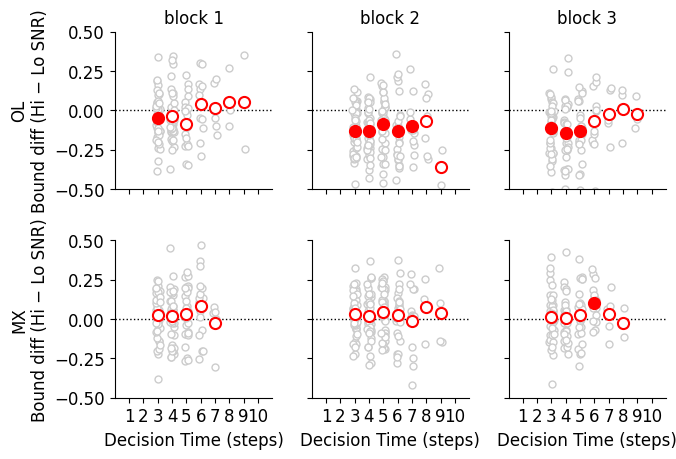

Saved /Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Projects/2025_Pigeon/Figures/Figure05S1_boundDiffByDT_formatted.pdf


In [ ]:
CM  = 1 / 2.54
WID = 14.0
HTS = [4.0, 4.0]
PSH = 1.3
PSW = 1.0
FS  = 12

n_rows  = len(tasks)
n_cols  = len(BLOCKS)
fig_h   = sum(HTS) + PSH * (n_rows - 1)
panel_w = (WID - PSW * (n_cols - 1)) / n_cols

hspace = PSH / np.mean(HTS)
wspace = PSW / panel_w

plt.rcParams.update({'font.size': FS, 'axes.labelsize': FS, 'axes.titlesize': FS})

rng_plot = np.random.default_rng(99)

fig = plt.figure(figsize=(WID * CM, fig_h * CM))
gs = gridspec.GridSpec(n_rows, n_cols, figure=fig,
                       left=0, right=1, bottom=0, top=1,
                       hspace=hspace, wspace=wspace)
axs = np.array([[fig.add_subplot(gs[r, c])
                 for c in range(n_cols)] for r in range(n_rows)])

for row_idx, (data_table, task_label, task_type) in enumerate(tasks):
    for col_idx, block in enumerate(BLOCKS):
        ax = axs[row_idx, col_idx]
        _plot_diff_panel(ax, data_table, block, MIN_DT, MAX_RT, rng_plot)

        if row_idx == 0:
            ax.set_title(BLOCK_LABELS[block])

        if col_idx == 0:
            ax.set_ylabel(f'{task_type}\nBound diff (Hi − Lo SNR)')
        else:
            ax.tick_params(axis='y', labelleft=False)

        if row_idx == n_rows - 1:
            ax.set_xlabel('Decision Time (steps)')
        else:
            ax.tick_params(axis='x', labelbottom=False)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

out = FIGURES_DIR / 'Figure05_S01.pdf'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {out}')